# EDA — Telco Customer Churn

Dataset: IBM Telco Customer Churn (~7.000 registros, 20 features, target `Churn`)

## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Carregamento e Inspeção Inicial

In [35]:
df = pd.read_csv('../data/raw/dataset.csv')

print(f'Shape: {df.shape}')
print(f'Duplicatas: {df.duplicated().sum()}')
df.head()

Shape: (7043, 21)
Duplicatas: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [36]:
# Informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
print(df.info())

print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
df.describe()


=== INFORMAÇÕES GERAIS DO DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pap

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### 2.1 Análise de missing values

In [37]:
# Análise de valores ausentes
print("=== ANÁLISE DE MISSING VALUES ===\n")

missing_values = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
    by='Missing_Percentage', ascending=False
)

if len(missing_values) > 0:
    print(missing_values)
    
    # Visualizar missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='coral')
    plt.xlabel('Porcentagem de Missing Values (%)')
    plt.title('Distribuição de Missing Values por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum missing value detectado!")

=== ANÁLISE DE MISSING VALUES ===

Nenhum missing value detectado!


## 3. TotalCharges — valores não numéricos

`TotalCharges` é lida como `object`. Contém espaços em branco (`" "`) em clientes com `tenure=0`.

In [40]:
# Linhas com espaço em TotalCharges
espacos = df[df['TotalCharges'].str.strip() == '']
print(f'Linhas com espaço: {len(espacos)}')
espacos[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Linhas com espaço: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [41]:
# Conversão: str -> float, espaços viram NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
print(f'NaN após conversão: {df["TotalCharges"].isnull().sum()}')

# Imputação com mediana (conforme spec)
mediana_tc = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(mediana_tc)
print(f'Mediana usada para imputação: {mediana_tc:.2f}')
print(f'NaN após imputação: {df["TotalCharges"].isnull().sum()}')

NaN após conversão: 11
Mediana usada para imputação: 1397.47
NaN após imputação: 0


In [42]:
# Encode target
df['Churn_bin'] = df['Churn'].map({'Yes': 1, 'No': 0})

## 4. Distribuição do Target

In [43]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Contagem:')
print(churn_counts)
print('\nProporção (%):')
print(churn_pct.round(1))

n_neg = churn_counts['No']
n_pos = churn_counts['Yes']
pos_weight = n_neg / n_pos
print(f'\npos_weight (BCEWithLogitsLoss) = {n_neg}/{n_pos} = {pos_weight:.4f}')

Contagem:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporção (%):
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64

pos_weight (BCEWithLogitsLoss) = 5174/1869 = 2.7683


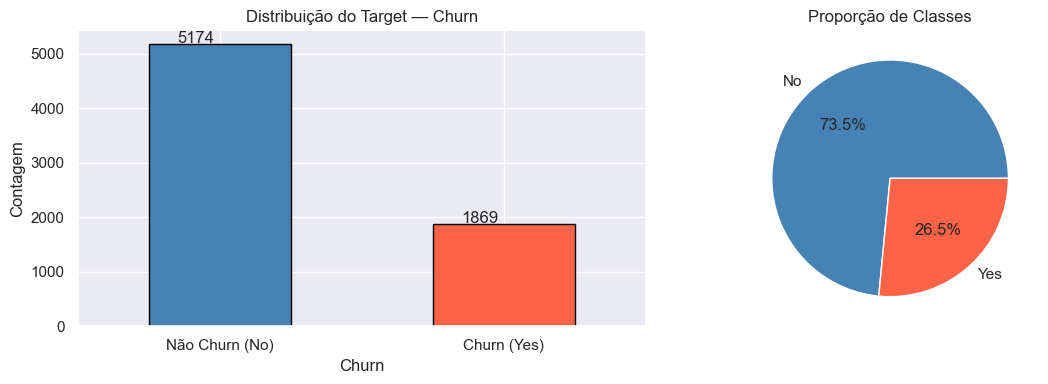


Dataset desbalanceado: 73.5% No vs 26.5% Yes
Justifica uso de pos_weight=2.77 no BCEWithLogitsLoss
Métrica principal: Recall (FN custa 20x mais que FP) + PR-AUC como técnica


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Distribuição do Target — Churn')
axes[0].set_xticklabels(['Não Churn (No)', 'Churn (Yes)'], rotation=0)
axes[0].set_ylabel('Contagem')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + 0.1, p.get_height() + 30))

churn_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
               colors=['steelblue', 'tomato'], labels=['No', 'Yes'])
axes[1].set_title('Proporção de Classes')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f'\nDataset desbalanceado: 73.5% No vs 26.5% Yes')
print(f'Justifica uso de pos_weight={pos_weight:.2f} no BCEWithLogitsLoss')
print(f'Métrica principal: Recall (FN custa 20x mais que FP) + PR-AUC como técnica')

## 5. Features Numéricas

In [45]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


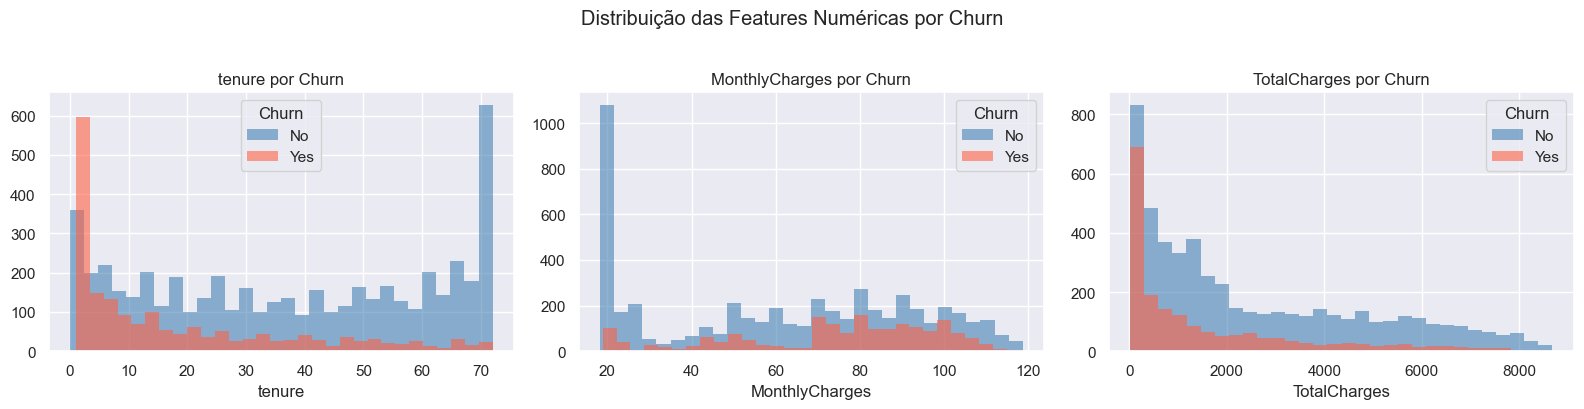

In [46]:
# Histogramas por classe
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, num_cols):
    for label, color in [('No', 'steelblue'), ('Yes', 'tomato')]:
        ax.hist(df[df['Churn'] == label][col], bins=30, alpha=0.6,
                label=label, color=color, edgecolor='none')
    ax.set_title(f'{col} por Churn')
    ax.set_xlabel(col)
    ax.legend(title='Churn')

plt.suptitle('Distribuição das Features Numéricas por Churn', y=1.02)
plt.tight_layout()
plt.show()

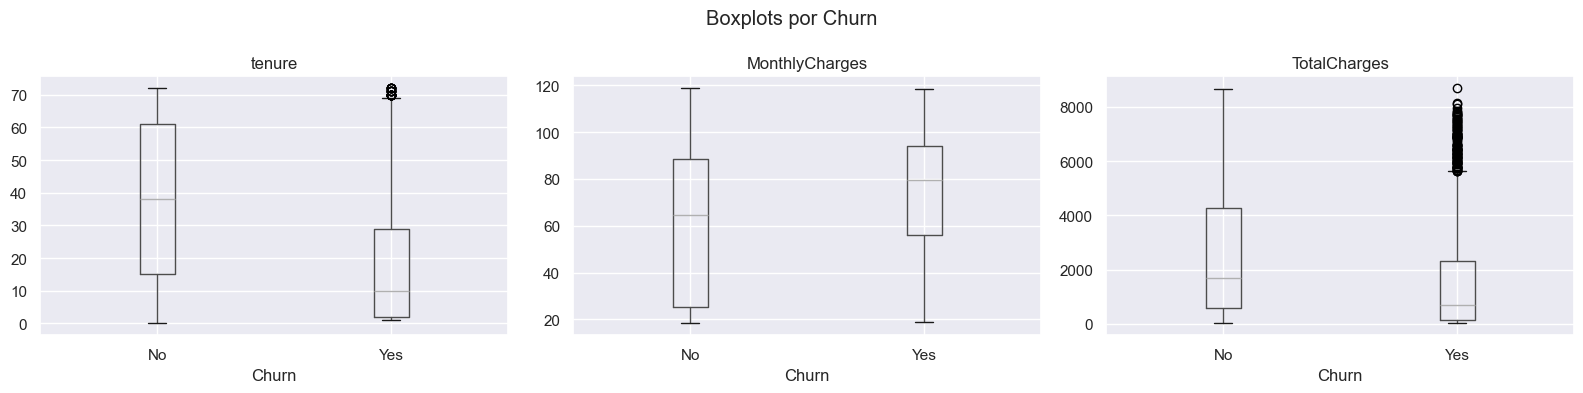

In [47]:
# Boxplots por classe
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, by='Churn', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Churn')

plt.suptitle('Boxplots por Churn')
plt.tight_layout()
plt.show()

In [48]:
# Correlação com target
print('=== Correlação (Pearson) com Churn_bin ===')
for col in num_cols:
    corr = df[col].corr(df['Churn_bin'])
    print(f'  {col:20s}: {corr:+.4f}')

print('\nInterpretação:')
print('  tenure: -0.35  — clientes mais antigos churnam menos (retidos)')
print('  MonthlyCharges: +0.19 — mensalidade alta associada a churn')
print('  TotalCharges: -0.20   — negativo por ser produto de tenure x charges')

=== Correlação (Pearson) com Churn_bin ===
  tenure              : -0.3522
  MonthlyCharges      : +0.1934
  TotalCharges        : -0.1990

Interpretação:
  tenure: -0.35  — clientes mais antigos churnam menos (retidos)
  MonthlyCharges: +0.19 — mensalidade alta associada a churn
  TotalCharges: -0.20   — negativo por ser produto de tenure x charges


## 6. Correlação entre Features (Multicolinearidade)

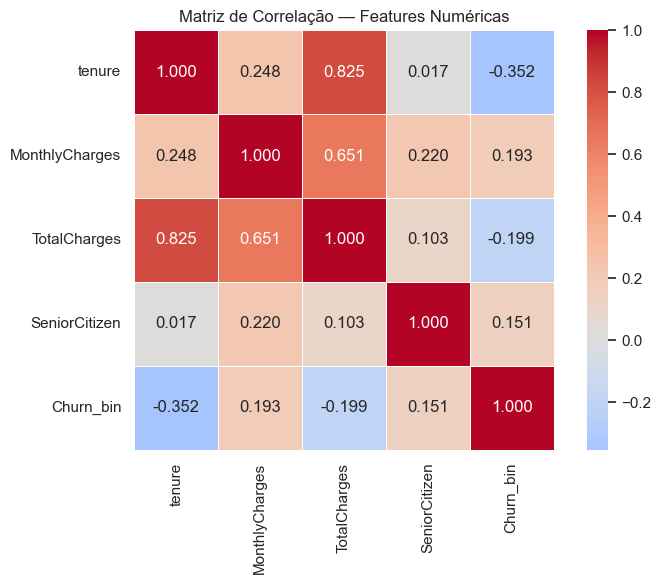


tenure x TotalCharges: 0.8255
ATENÇÃO: correlação 0.825 — próxima do threshold 0.85
TotalCharges é aproximadamente tenure × MonthlyCharges — redundância conceitual


In [49]:
corr_num = df[num_cols + ['SeniorCitizen', 'Churn_bin']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_num, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlação — Features Numéricas')
plt.tight_layout()
plt.show()

tc_tenure = df['tenure'].corr(df['TotalCharges'])
print(f'\ntenure x TotalCharges: {tc_tenure:.4f}')
print(f'ATENÇÃO: correlação {tc_tenure:.3f} — próxima do threshold 0.85')
print('TotalCharges é aproximadamente tenure × MonthlyCharges — redundância conceitual')

In [50]:
# Verificar pares com correlação > 0.85
corr_matrix = df[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(c, r, corr_matrix.loc[r, c])
             for c in upper.columns for r in upper.index
             if pd.notna(upper.loc[r, c]) and upper.loc[r, c] > 0.85]

if high_corr:
    print('Pares com correlação > 0.85:')
    for a, b, v in high_corr:
        print(f'  {a} x {b}: {v:.4f}')
else:
    print('Nenhum par com correlação > 0.85 entre numéricas')

print(f'\ntenure x TotalCharges = {df["tenure"].corr(df["TotalCharges"]):.4f} (abaixo de 0.85 mas candidata a drop)')

Nenhum par com correlação > 0.85 entre numéricas

tenure x TotalCharges = 0.8255 (abaixo de 0.85 mas candidata a drop)


## 7. Features Categóricas — Taxa de Churn por Categoria

In [51]:
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod']

for col in cat_cols:
    rates = df.groupby(col)['Churn_bin'].agg(['mean', 'count']).reset_index()
    rates.columns = [col, 'churn_rate', 'count']
    rates['churn_rate'] = (rates['churn_rate'] * 100).round(1)
    rates = rates.sort_values('churn_rate', ascending=False)
    print(rates.to_string(index=False))
    print()

gender  churn_rate  count
Female        26.9   3488
  Male        26.2   3555

Partner  churn_rate  count
     No        33.0   3641
    Yes        19.7   3402

Dependents  churn_rate  count
        No        31.3   4933
       Yes        15.5   2110

PhoneService  churn_rate  count
         Yes        26.7   6361
          No        24.9    682

   MultipleLines  churn_rate  count
             Yes        28.6   2971
              No        25.0   3390
No phone service        24.9    682

InternetService  churn_rate  count
    Fiber optic        41.9   3096
            DSL        19.0   2421
             No         7.4   1526

     OnlineSecurity  churn_rate  count
                 No        41.8   3498
                Yes        14.6   2019
No internet service         7.4   1526

       OnlineBackup  churn_rate  count
                 No        39.9   3088
                Yes        21.5   2429
No internet service         7.4   1526

   DeviceProtection  churn_rate  count
            

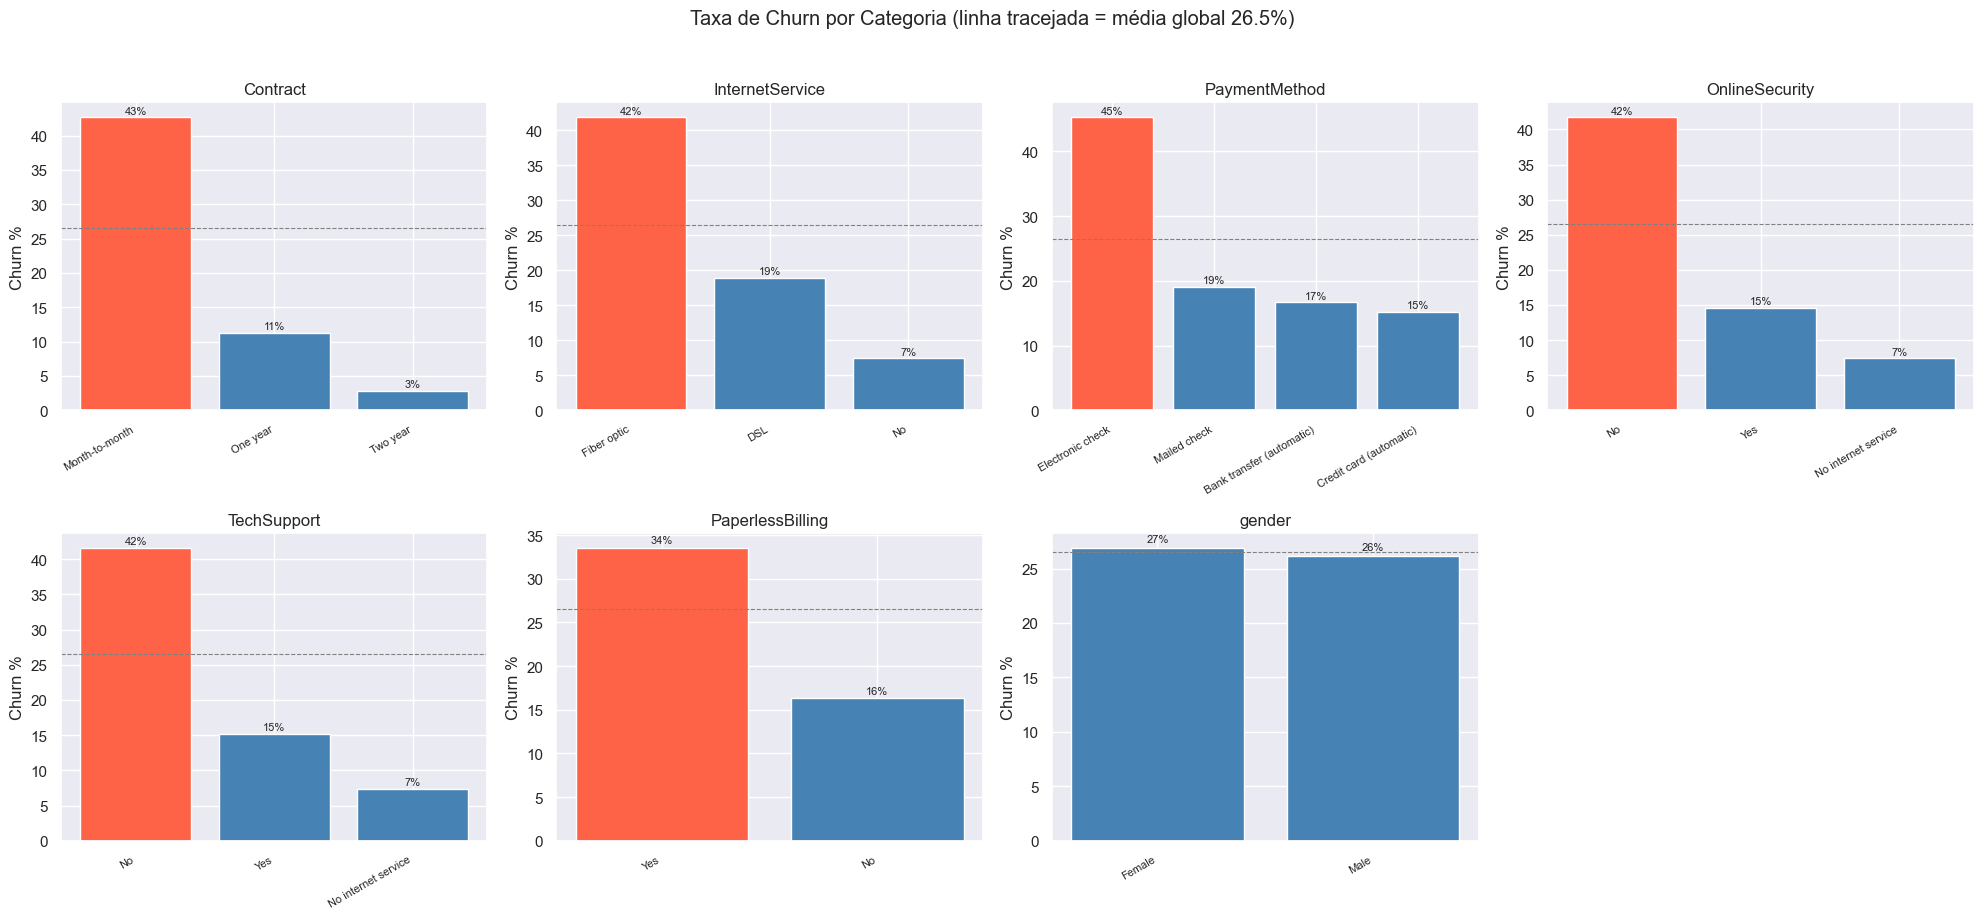

In [52]:
# Visualizar features mais discriminativas
top_cats = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity',
            'TechSupport', 'PaperlessBilling', 'gender']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for ax, col in zip(axes, top_cats):
    rates = df.groupby(col)['Churn_bin'].mean().sort_values(ascending=False)
    bars = ax.bar(range(len(rates)), rates.values * 100,
                  color=['tomato' if v > 0.3 else 'steelblue' for v in rates.values])
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index, rotation=30, ha='right', fontsize=8)
    ax.set_title(col)
    ax.set_ylabel('Churn %')
    ax.axhline(26.5, color='gray', linestyle='--', linewidth=0.8, label='Média')
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val*100:.0f}%', ha='center', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Taxa de Churn por Categoria (linha tracejada = média global 26.5%)', y=1.02)
plt.tight_layout()
plt.show()

## 8. Análise de StreamingTV vs StreamingMovies (possível redundância)

In [53]:
cross = pd.crosstab(df['StreamingTV'], df['StreamingMovies'], normalize='all') * 100
print('Cross-tab StreamingTV x StreamingMovies (%):')
print(cross.round(1))

tv_rate = df.groupby('StreamingTV')['Churn_bin'].mean()
mov_rate = df.groupby('StreamingMovies')['Churn_bin'].mean()
print('\nChurn rate StreamingTV:', tv_rate.round(3).to_dict())
print('Churn rate StreamingMovies:', mov_rate.round(3).to_dict())
print('\nDistribuições e taxas de churn são quase idênticas — possível redundância')

Cross-tab StreamingTV x StreamingMovies (%):
StreamingMovies        No  No internet service   Yes
StreamingTV                                         
No                   28.7                  0.0  11.2
No internet service   0.0                 21.7   0.0
Yes                  10.9                  0.0  27.5

Churn rate StreamingTV: {'No': 0.335, 'No internet service': 0.074, 'Yes': 0.301}
Churn rate StreamingMovies: {'No': 0.337, 'No internet service': 0.074, 'Yes': 0.299}

Distribuições e taxas de churn são quase idênticas — possível redundância


## 9. Resumo dos Achados e Decisões

In [54]:
n_neg = (df['Churn'] == 'No').sum()
n_pos = (df['Churn'] == 'Yes').sum()
pos_weight = n_neg / n_pos

print('=' * 60)
print('RESUMO EDA — DECISÕES PARA MODELAGEM')
print('=' * 60)
print()
print(f'Dataset: {df.shape[0]} registros, {df.shape[1]-2} features (sem customerID/Churn_bin)')
print(f'Duplicatas: 0')
print(f'TotalCharges: 11 linhas com espaço → imputadas com mediana ({mediana_tc:.2f})')
print()
print('--- TARGET ---')
print(f'  No Churn: {n_neg} ({n_neg/len(df)*100:.1f}%)')
print(f'  Churn:    {n_pos} ({n_pos/len(df)*100:.1f}%)')
print(f'  Desbalanceamento: {pos_weight:.2f}x')
print()
print('--- MÉTRICAS ---')
print('  Principal: Recall >= 0.75 (restrição de negócio, FN custa 20x)')
print('  Técnica: PR-AUC (mais informativa que AUC-ROC em dados desbalanceados)')
print('  Threshold: otimizar por Expected Profit = TP*1140 - FP*60 - FN*1200')
print()
print('--- POS_WEIGHT ---')
print(f'  pos_weight = {n_neg}/{n_pos} = {pos_weight:.4f}')
print()
print('--- CORRELAÇÕES CRÍTICAS ---')
print(f'  tenure x TotalCharges: 0.826 (abaixo de 0.85, mas redundância conceitual)')
print(f'  StreamingTV x StreamingMovies: distribuições quase idênticas')
print()
print('--- FEATURES CANDIDATAS A DROP ---')
print('  gender: churn 26.9% vs 26.2% — sem poder discriminativo')
print('  TotalCharges: alta correlação com tenure (0.826) — avaliar no pipeline')
print('  PhoneService: churn 26.7% vs 24.9% — sinal fraco')
print()
print('--- FEATURES MAIS PREDITIVAS ---')
print('  Contract (Month-to-month: 42.7% vs Two year: 2.8%)')
print('  InternetService (Fiber optic: 41.9% vs No: 7.4%)')
print('  PaymentMethod (Electronic check: 45.3%)')
print('  OnlineSecurity / TechSupport (~42% sem vs ~15% com serviço)')
print('  tenure (correlação -0.35 com churn)')

RESUMO EDA — DECISÕES PARA MODELAGEM

Dataset: 7043 registros, 20 features (sem customerID/Churn_bin)
Duplicatas: 0
TotalCharges: 11 linhas com espaço → imputadas com mediana (1397.47)

--- TARGET ---
  No Churn: 5174 (73.5%)
  Churn:    1869 (26.5%)
  Desbalanceamento: 2.77x

--- MÉTRICAS ---
  Principal: Recall >= 0.75 (restrição de negócio, FN custa 20x)
  Técnica: PR-AUC (mais informativa que AUC-ROC em dados desbalanceados)
  Threshold: otimizar por Expected Profit = TP*1140 - FP*60 - FN*1200

--- POS_WEIGHT ---
  pos_weight = 5174/1869 = 2.7683

--- CORRELAÇÕES CRÍTICAS ---
  tenure x TotalCharges: 0.826 (abaixo de 0.85, mas redundância conceitual)
  StreamingTV x StreamingMovies: distribuições quase idênticas

--- FEATURES CANDIDATAS A DROP ---
  gender: churn 26.9% vs 26.2% — sem poder discriminativo
  TotalCharges: alta correlação com tenure (0.826) — avaliar no pipeline
  PhoneService: churn 26.7% vs 24.9% — sinal fraco

--- FEATURES MAIS PREDITIVAS ---
  Contract (Month-to-m